# Experiment 7: Dimensionality Reduction and Model Evaluation (With and Without PCA)

**Objective:** Study the effect of PCA on the performance of various ML classifiers, with hyperparameter tuning and 5-fold cross-validation, comparing No-PCA vs With-PCA settings.

**Dataset:** Breast Cancer Wisconsin (Diagnostic) dataset, loaded via `sklearn.datasets.load_breast_cancer`.
- Samples: 569
- Features: 30 numeric features
- Target classes: Malignant (0), Benign (1)
- Preprocessing: StandardScaler (no missing values, no categorical encoding needed)


In [1]:
# 1. Imports
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                               GradientBoostingClassifier, StackingClassifier)
from sklearn.metrics import (accuracy_score, f1_score, roc_curve, auc,
                              precision_recall_curve, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed; XGBoost model will be skipped. Install with `pip install xgboost` to include it.")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


xgboost not installed; XGBoost model will be skipped. Install with `pip install xgboost` to include it.


## 2. Load Dataset and Basic Exploration

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Target classes:", dict(zip(data.target_names, [0,1])))
print("\nClass distribution:")
print(y.value_counts().rename(index={0:'malignant',1:'benign'}))

X.head()


Number of samples: 569
Number of features: 30
Target classes: {np.str_('malignant'): 0, np.str_('benign'): 1}

Class distribution:
target
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Missing values per column (sum): 0


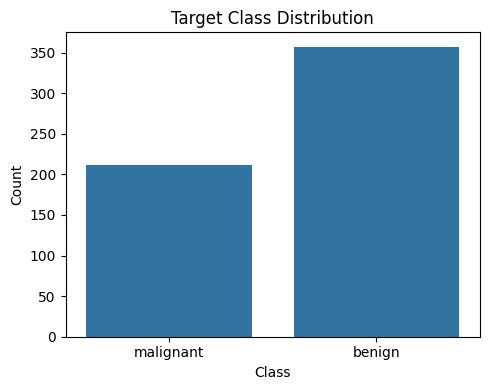

In [3]:
# No missing values in this dataset, but check anyway
print("Missing values per column (sum):", X.isnull().sum().sum())

# Class distribution plot
plt.figure(figsize=(5,4))
sns.countplot(x=y.map({0:'malignant',1:'benign'}))
plt.title('Target Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


## 3. Train-Test Split and Preprocessing

We hold out a test set for final evaluation (ROC/PR curves, confusion matrices), and use 5-fold cross-validation on the training set for hyperparameter tuning and model comparison.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)


Train shape: (455, 30)
Test shape: (114, 30)


## 4. PCA — Scree Plot and Component Selection

We choose the number of PCA components that explain **95% of variance**.


Number of components needed for 95% variance: 10
Explained variance with 10 components: 95.27%


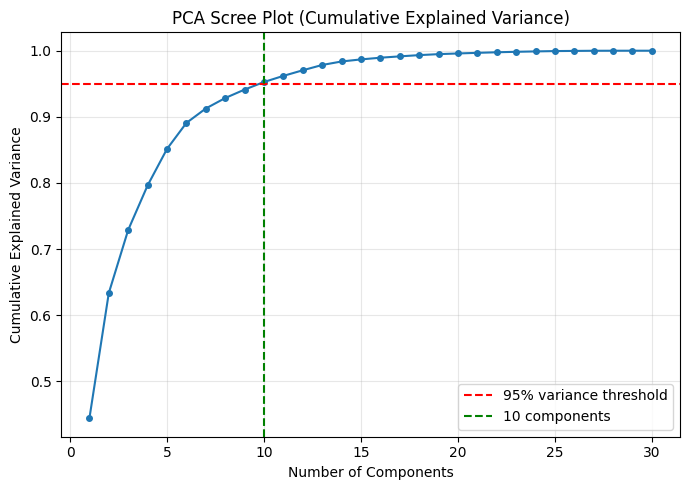

,Setting,Chosen Components / Variance Target,Explained Variance (%),Justification
0,With-PCA,10 components (95% variance target),95.27,95% variance retained while reducing dimension...


In [5]:
pca_full = PCA(random_state=RANDOM_STATE).fit(X_train_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

n_components_95 = np.argmax(cum_var >= 0.95) + 1
print(f"Number of components needed for 95% variance: {n_components_95}")
print(f"Explained variance with {n_components_95} components: {cum_var[n_components_95-1]*100:.2f}%")

plt.figure(figsize=(7,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', markersize=4)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance threshold')
plt.axvline(x=n_components_95, color='g', linestyle='--', label=f'{n_components_95} components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree Plot (Cumulative Explained Variance)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

pca_summary = pd.DataFrame({
    'Setting': ['With-PCA'],
    'Chosen Components / Variance Target': [f'{n_components_95} components (95% variance target)'],
    'Explained Variance (%)': [round(cum_var[n_components_95-1]*100, 2)],
    'Justification': ['95% variance retained while reducing dimensionality from 30 to fewer features']
})
pca_summary


In [6]:
N_COMPONENTS = n_components_95

def make_pca():
    return PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)


## 5. Model Definitions and Hyperparameter Grids

For each model we define a small hyperparameter grid. We build two pipelines per model:
- **No-PCA**: `StandardScaler -> Model`
- **With-PCA**: `StandardScaler -> PCA -> Model`

`GridSearchCV` with 5-fold CV is used for tuning; the best estimator's CV results are then used for the fold-wise comparison table.


In [7]:
base_learners = [
    ('dt', DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ('knn', KNeighborsClassifier())
]
meta_learner = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)

model_configs = {
    'SVM': {
        'estimator': SVC(probability=True, random_state=RANDOM_STATE),
        'param_grid': {
            'model__C': [0.1, 1, 10],
            'model__gamma': ['scale', 0.01, 0.1],
            'model__kernel': ['rbf', 'linear']
        }
    },
    'Naive Bayes': {
        'estimator': GaussianNB(),
        'param_grid': {
            'model__var_smoothing': [1e-9, 1e-8, 1e-7]
        }
    },
    'KNN': {
        'estimator': KNeighborsClassifier(),
        'param_grid': {
            'model__n_neighbors': [3, 5, 7, 9],
            'model__weights': ['uniform', 'distance'],
            'model__metric': ['euclidean', 'manhattan']
        }
    },
    'Logistic Regression': {
        'estimator': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        'param_grid': {
            'model__C': [0.01, 0.1, 1, 10],
            'model__penalty': ['l2'],
            'model__solver': ['lbfgs']
        }
    },
    'Decision Tree': {
        'estimator': DecisionTreeClassifier(random_state=RANDOM_STATE),
        'param_grid': {
            'model__max_depth': [3, 5, 10, None],
            'model__min_samples_split': [2, 5, 10],
            'model__criterion': ['gini', 'entropy']
        }
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(random_state=RANDOM_STATE),
        'param_grid': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [None, 10, 20],
            'model__min_samples_split': [2, 5]
        }
    },
    'AdaBoost': {
        'estimator': AdaBoostClassifier(random_state=RANDOM_STATE),
        'param_grid': {
            'model__n_estimators': [50, 100, 200],
            'model__learning_rate': [0.01, 0.1, 1.0]
        }
    },
    'Gradient Boosting': {
        'estimator': GradientBoostingClassifier(random_state=RANDOM_STATE),
        'param_grid': {
            'model__n_estimators': [100, 200],
            'model__learning_rate': [0.01, 0.1],
            'model__max_depth': [2, 3]
        }
    },
    'Stacking': {
        'estimator': StackingClassifier(estimators=base_learners, final_estimator=meta_learner, cv=5),
        'param_grid': {
            'model__dt__max_depth': [3, 5],
            'model__knn__n_neighbors': [3, 5]
        }
    }
}

if HAS_XGB:
    model_configs['XGBoost'] = {
        'estimator': XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
        'param_grid': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [3, 5],
            'model__learning_rate': [0.01, 0.1]
        }
    }

print("Models configured:", list(model_configs.keys()))


Models configured: ['SVM', 'Naive Bayes', 'KNN', 'Logistic Regression', 'Decision Tree', 'Random Forest', 'AdaBoost', 'Gradient Boosting', 'Stacking']


## 6. Tuning + 5-Fold Cross-Validation Runner

For each model and each setting (No-PCA / With-PCA):
1. Build the pipeline (`StandardScaler` [+ `PCA`] + model).
2. Run `GridSearchCV` (5-fold, scoring = accuracy) on the training set to find the best hyperparameters.
3. Run `cross_validate` with the best hyperparameters on the training set (5-fold) to record fold-wise accuracy and F1.
4. Fit the best estimator on the full training set and evaluate on the held-out test set.


In [8]:
def build_pipeline(estimator, use_pca):
    steps = [('scaler', StandardScaler())]
    if use_pca:
        steps.append(('pca', make_pca()))
    steps.append(('model', estimator))
    return Pipeline(steps)

def tune_and_cv(name, estimator, param_grid, use_pca, X_tr, y_tr):
    pipe = build_pipeline(estimator, use_pca)
    gs = GridSearchCV(pipe, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
    gs.fit(X_tr, y_tr)
    best_pipe = gs.best_estimator_

    scoring = {'accuracy': 'accuracy', 'f1': 'f1'}
    cvres = cross_validate(best_pipe, X_tr, y_tr, cv=cv, scoring=scoring, n_jobs=-1)

    result = {
        'model': name,
        'use_pca': use_pca,
        'best_params': gs.best_params_,
        'fold_accuracy': cvres['test_accuracy'],
        'fold_f1': cvres['test_f1'],
        'avg_accuracy': cvres['test_accuracy'].mean(),
        'avg_f1': cvres['test_f1'].mean(),
        'std_accuracy': cvres['test_accuracy'].std(),
        'fitted_pipeline': best_pipe
    }
    return result

all_results = {}
X_train_raw = X_train.values  # unscaled; pipeline applies StandardScaler internally
X_test_raw = X_test.values

for name, cfg in model_configs.items():
    for use_pca in [False, True]:
        key = f"{name} | {'With-PCA' if use_pca else 'No-PCA'}"
        print(f"Tuning: {key} ...")
        res = tune_and_cv(name, cfg['estimator'], cfg['param_grid'], use_pca, X_train_raw, y_train.values)
        all_results[key] = res
        print(f"  Best params: {res['best_params']}")
        print(f"  Avg CV Accuracy: {res['avg_accuracy']:.4f} | Avg CV F1: {res['avg_f1']:.4f}")

print("\nAll models tuned and cross-validated.")


Tuning: SVM | No-PCA ...
  Best params: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
  Avg CV Accuracy: 0.9758 | Avg CV F1: 0.9810
Tuning: SVM | With-PCA ...
  Best params: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'linear'}
  Avg CV Accuracy: 0.9802 | Avg CV F1: 0.9843
Tuning: Naive Bayes | No-PCA ...
  Best params: {'model__var_smoothing': 1e-09}
  Avg CV Accuracy: 0.9341 | Avg CV F1: 0.9478
Tuning: Naive Bayes | With-PCA ...
  Best params: {'model__var_smoothing': 1e-09}
  Avg CV Accuracy: 0.9275 | Avg CV F1: 0.9433
Tuning: KNN | No-PCA ...
  Best params: {'model__metric': 'manhattan', 'model__n_neighbors': 3, 'model__weights': 'uniform'}
  Avg CV Accuracy: 0.9714 | Avg CV F1: 0.9774
Tuning: KNN | With-PCA ...
  Best params: {'model__metric': 'euclidean', 'model__n_neighbors': 3, 'model__weights': 'uniform'}
  Avg CV Accuracy: 0.9670 | Avg CV F1: 0.9741
Tuning: Logistic Regression | No-PCA ...
  Best params: {'model__C': 0.1, 'model__penalty

## 7. Hyperparameter Tuning Result Tables (Per Model)

In [9]:
def get_pair(name):
    no_pca = all_results[f"{name} | No-PCA"]
    with_pca = all_results[f"{name} | With-PCA"]
    return no_pca, with_pca

# --- SVM table ---
no_pca, with_pca = get_pair('SVM')
svm_table = pd.DataFrame({
    'Kernel': [no_pca['best_params'].get('model__kernel'), with_pca['best_params'].get('model__kernel')],
    'C': [no_pca['best_params'].get('model__C'), with_pca['best_params'].get('model__C')],
    'Gamma': [no_pca['best_params'].get('model__gamma'), with_pca['best_params'].get('model__gamma')],
    'Avg CV Accuracy': [no_pca['avg_accuracy'], with_pca['avg_accuracy']],
    'Avg CV F1': [no_pca['avg_f1'], with_pca['avg_f1']]
}, index=['No-PCA', 'With-PCA'])
print("SVM — Hyperparameter Tuning Results")
svm_table


SVM — Hyperparameter Tuning Results


,Kernel,C,Gamma,Avg CV Accuracy,Avg CV F1
No-PCA,linear,0.1,scale,0.975824,0.981015
With-PCA,linear,10.0,scale,0.980220,0.984347


In [10]:
# --- Naive Bayes table ---
no_pca, with_pca = get_pair('Naive Bayes')
nb_table = pd.DataFrame({
    'Smoothing Parameter': [no_pca['best_params'].get('model__var_smoothing'), with_pca['best_params'].get('model__var_smoothing')],
    'Avg CV Accuracy': [no_pca['avg_accuracy'], with_pca['avg_accuracy']],
    'Avg CV F1': [no_pca['avg_f1'], with_pca['avg_f1']]
}, index=['No-PCA', 'With-PCA'])
print("Naive Bayes — Smoothing Choices")
nb_table


Naive Bayes — Smoothing Choices


,Smoothing Parameter,Avg CV Accuracy,Avg CV F1
No-PCA,1.000000e-09,0.934066,0.947761
With-PCA,1.000000e-09,0.927473,0.943312


In [11]:
# --- KNN table ---
no_pca, with_pca = get_pair('KNN')
knn_table = pd.DataFrame({
    'k': [no_pca['best_params'].get('model__n_neighbors'), with_pca['best_params'].get('model__n_neighbors')],
    'Weights': [no_pca['best_params'].get('model__weights'), with_pca['best_params'].get('model__weights')],
    'Distance Metric': [no_pca['best_params'].get('model__metric'), with_pca['best_params'].get('model__metric')],
    'Avg CV Accuracy': [no_pca['avg_accuracy'], with_pca['avg_accuracy']],
    'Avg CV F1': [no_pca['avg_f1'], with_pca['avg_f1']]
}, index=['No-PCA', 'With-PCA'])
print("KNN — Hyperparameter Tuning")
knn_table


KNN — Hyperparameter Tuning


,k,Weights,Distance Metric,Avg CV Accuracy,Avg CV F1
No-PCA,3,uniform,manhattan,0.971429,0.977390
With-PCA,3,uniform,euclidean,0.967033,0.974059


In [12]:
# --- Remaining models: Logistic Regression, Decision Tree, Random Forest, AdaBoost,
# Gradient Boosting, XGBoost, Stacking ---
remaining_models = ['Logistic Regression', 'Decision Tree', 'Random Forest',
                     'AdaBoost', 'Gradient Boosting', 'Stacking']
if HAS_XGB:
    remaining_models.append('XGBoost')

for name in remaining_models:
    no_pca, with_pca = get_pair(name)
    tbl = pd.DataFrame({
        'Best Params': [no_pca['best_params'], with_pca['best_params']],
        'Avg CV Accuracy': [no_pca['avg_accuracy'], with_pca['avg_accuracy']],
        'Avg CV F1': [no_pca['avg_f1'], with_pca['avg_f1']]
    }, index=['No-PCA', 'With-PCA'])
    print(f"\n{name} — Hyperparameter Tuning Results")
    display(tbl)



Logistic Regression — Hyperparameter Tuning Results


,Best Params,Avg CV Accuracy,Avg CV F1
No-PCA,"{'model__C': 0.1, 'model__penalty': 'l2', 'mod...",0.982418,0.986116
With-PCA,"{'model__C': 1, 'model__penalty': 'l2', 'model...",0.982418,0.986086



Decision Tree — Hyperparameter Tuning Results


,Best Params,Avg CV Accuracy,Avg CV F1
No-PCA,"{'model__criterion': 'entropy', 'model__max_de...",0.931868,0.946350
With-PCA,"{'model__criterion': 'entropy', 'model__max_de...",0.936264,0.948658



Random Forest — Hyperparameter Tuning Results


...

,Best Params,Avg CV Accuracy,Avg CV F1
No-PCA,"{'model__learning_rate': 1.0, 'model__n_estima...",0.980220,0.984378
With-PCA,"{'model__learning_rate': 1.0, 'model__n_estima...",0.975824,0.981076



Gradient Boosting — Hyperparameter Tuning Results


,Best Params,Avg CV Accuracy,Avg CV F1
No-PCA,"{'model__learning_rate': 0.1, 'model__max_dept...",0.967033,0.973726
With-PCA,"{'model__learning_rate': 0.1, 'model__max_dept...",0.962637,0.970337



Stacking — Hyperparameter Tuning Results


,Best Params,Avg CV Accuracy,Avg CV F1
No-PCA,"{'model__dt__max_depth': 5, 'model__knn__n_nei...",0.969231,0.97571
With-PCA,"{'model__dt__max_depth': 5, 'model__knn__n_nei...",0.971429,0.97748


## 8. 5-Fold Cross-Validation Results Table (All Models, No-PCA vs With-PCA)

In [13]:
all_model_names = list(model_configs.keys())

rows_acc = []
for name in all_model_names:
    no_pca, with_pca = get_pair(name)
    row = {'Model': name}
    for i in range(5):
        row[f'Fold {i+1} (No-PCA)'] = round(no_pca['fold_accuracy'][i], 4)
    row['Avg (No-PCA)'] = round(no_pca['avg_accuracy'], 4)
    for i in range(5):
        row[f'Fold {i+1} (With-PCA)'] = round(with_pca['fold_accuracy'][i], 4)
    row['Avg (With-PCA)'] = round(with_pca['avg_accuracy'], 4)
    rows_acc.append(row)

cv_accuracy_table = pd.DataFrame(rows_acc).set_index('Model')
cv_accuracy_table


,Fold 1 (No-PCA),Fold 2 (No-PCA),Fold 3 (No-PCA),Fold 4 (No-PCA),Fold 5 (No-PCA),Avg (No-PCA),Fold 1 (With-PCA),Fold 2 (With-PCA),Fold 3 (With-PCA),Fold 4 (With-PCA),Fold 5 (With-PCA),Avg (With-PCA)
Model,,,,,,,,,,,,
SVM,0.9560,0.9780,0.9780,0.9780,0.9890,0.9758,0.9670,0.9890,0.9890,0.9780,0.9780,0.9802
Naive Bayes,0.9121,0.9670,0.8901,0.9560,0.9451,0.9341,0.9011,0.9451,0.9121,0.9451,0.9341,0.9275
KNN,0.9780,0.9890,0.9560,0.9560,0.9780,0.9714,0.9560,0.9890,0.9451,0.9670,0.9780,0.9670
Logistic Regression,0.9780,0.9780,0.9890,0.9780,0.9890,0.9824,0.9780,0.9890,0.9890,0.9780,0.9780,0.9824
Decision Tree,0.9011,0.9451,0.9121,0.9341,0.9670,0.9319,0.9011,0.9341,0.9341,0.9670,0.9451,0.9363
Random Forest,0.9670,0.9560,0.9341,0.9670,0.9890,0.9626,0.9341,0.9780,0.9341,0.9670,0.9890,0.9604
AdaBoost,0.9890,1.0000,0.9451,0.9780,0.9890,0.9802,0.9560,1.0000,0.9780,0.9560,0.9890,0.9758
Gradient Boosting,0.9560,0.9890,0.9451,0.9670,0.9780,0.9670,0.9451,0.9890,0.9231,0.9670,0.9890,0.9626
Stacking,0.9780,0.9780,0.9451,0.9670,0.9780,0.9692,0.9670,0.9890,0.9451,0.9670,0.9890,0.9714


In [14]:
# Simplified combined view: fold-wise accuracy, No-PCA vs With-PCA side by side
simple_rows = []
for name in all_model_names:
    no_pca, with_pca = get_pair(name)
    simple_rows.append({
        'Model': name,
        'Fold 1': f"{no_pca['fold_accuracy'][0]:.3f} / {with_pca['fold_accuracy'][0]:.3f}",
        'Fold 2': f"{no_pca['fold_accuracy'][1]:.3f} / {with_pca['fold_accuracy'][1]:.3f}",
        'Fold 3': f"{no_pca['fold_accuracy'][2]:.3f} / {with_pca['fold_accuracy'][2]:.3f}",
        'Fold 4': f"{no_pca['fold_accuracy'][3]:.3f} / {with_pca['fold_accuracy'][3]:.3f}",
        'Fold 5': f"{no_pca['fold_accuracy'][4]:.3f} / {with_pca['fold_accuracy'][4]:.3f}",
        'Avg (No-PCA)': round(no_pca['avg_accuracy'], 4),
        'Avg (With-PCA)': round(with_pca['avg_accuracy'], 4),
        'Std (No-PCA)': round(no_pca['std_accuracy'], 4),
        'Std (With-PCA)': round(with_pca['std_accuracy'], 4),
    })
summary_table = pd.DataFrame(simple_rows).set_index('Model')
print("Table 5: 5-Fold Cross-Validation Results (No-PCA vs With-PCA) — values shown as 'No-PCA / With-PCA'")
summary_table


Table 5: 5-Fold Cross-Validation Results (No-PCA vs With-PCA) — values shown as 'No-PCA / With-PCA'


,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Avg (No-PCA),Avg (With-PCA),Std (No-PCA),Std (With-PCA)
Model,,,,,,,,,
SVM,0.956 / 0.967,0.978 / 0.989,0.978 / 0.989,0.978 / 0.978,0.989 / 0.978,0.9758,0.9802,0.0108,0.0082
Naive Bayes,0.912 / 0.901,0.967 / 0.945,0.890 / 0.912,0.956 / 0.945,0.945 / 0.934,0.9341,0.9275,0.0287,0.0179
KNN,0.978 / 0.956,0.989 / 0.989,0.956 / 0.945,0.956 / 0.967,0.978 / 0.978,0.9714,0.9670,0.0132,0.0155
Logistic Regression,0.978 / 0.978,0.978 / 0.989,0.989 / 0.989,0.978 / 0.978,0.989 / 0.978,0.9824,0.9824,0.0054,0.0054
Decision Tree,0.901 / 0.901,0.945 / 0.934,0.912 / 0.934,0.934 / 0.967,0.967 / 0.945,0.9319,0.9363,0.0235,0.0213
Random Forest,0.967 / 0.934,0.956 / 0.978,0.934 / 0.934,0.967 / 0.967,0.989 / 0.989,0.9626,0.9604,0.0179,0.0226
AdaBoost,0.989 / 0.956,1.000 / 1.000,0.945 / 0.978,0.978 / 0.956,0.989 / 0.989,0.9802,0.9758,0.0189,0.0176
Gradient Boosting,0.956 / 0.945,0.989 / 0.989,0.945 / 0.923,0.967 / 0.967,0.978 / 0.989,0.9670,0.9626,0.0155,0.0256
Stacking,0.978 / 0.967,0.978 / 0.989,0.945 / 0.945,0.967 / 0.967,0.978 / 0.989,0.9692,0.9714,0.0128,0.0164


## 9. Comparison Bar Chart: Avg CV Accuracy (No-PCA vs With-PCA)

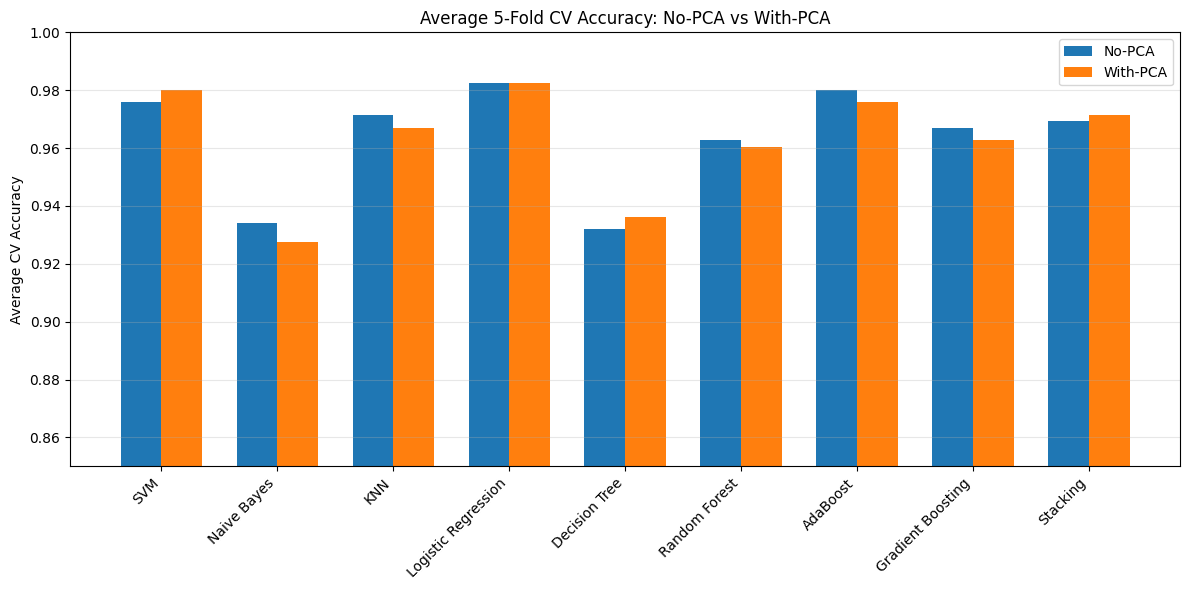

In [15]:
fig, ax = plt.subplots(figsize=(12,6))
x = np.arange(len(all_model_names))
width = 0.35

no_pca_scores = [all_results[f"{m} | No-PCA"]['avg_accuracy'] for m in all_model_names]
with_pca_scores = [all_results[f"{m} | With-PCA"]['avg_accuracy'] for m in all_model_names]

ax.bar(x - width/2, no_pca_scores, width, label='No-PCA')
ax.bar(x + width/2, with_pca_scores, width, label='With-PCA')
ax.set_xticks(x)
ax.set_xticklabels(all_model_names, rotation=45, ha='right')
ax.set_ylabel('Average CV Accuracy')
ax.set_title('Average 5-Fold CV Accuracy: No-PCA vs With-PCA')
ax.set_ylim(0.85, 1.0)
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## 10. ROC / PR Curves and Confusion Matrices (Selected Models, Test Set)

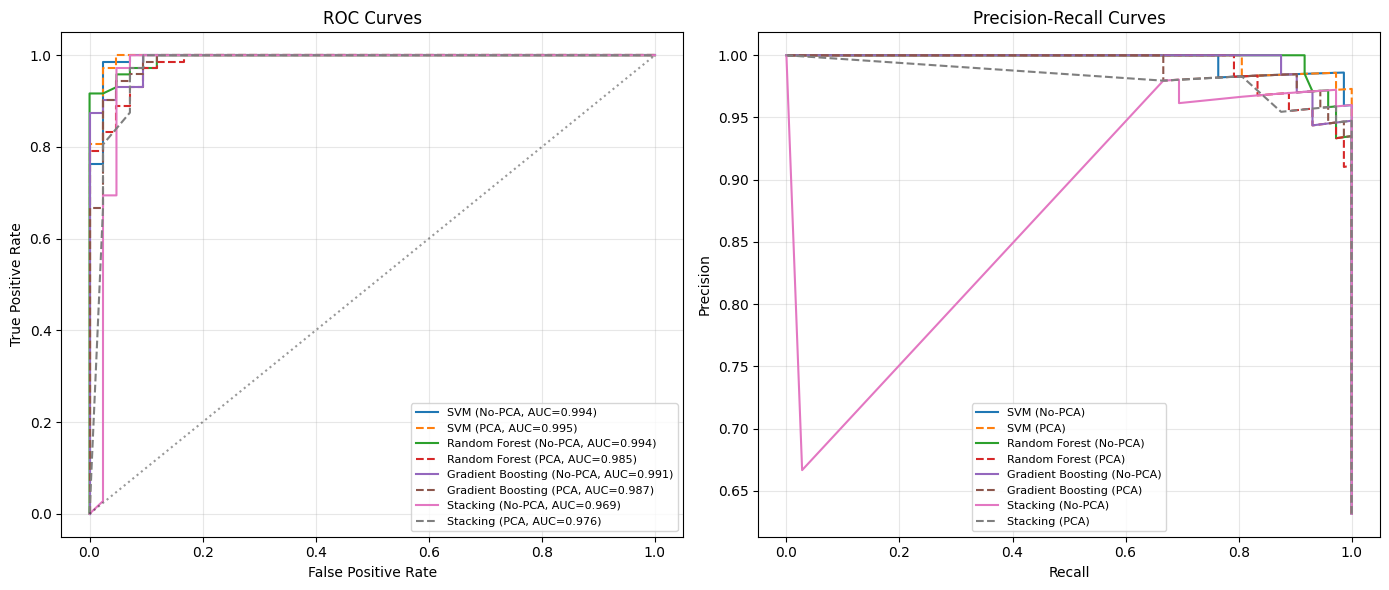

In [16]:
selected_models = ['SVM', 'Random Forest', 'Gradient Boosting', 'Stacking']
if HAS_XGB:
    selected_models.append('XGBoost')

fig, axes = plt.subplots(1, 2, figsize=(14,6))

for name in selected_models:
    for use_pca, style in [(False, '-'), (True, '--')]:
        res = all_results[f"{name} | {'With-PCA' if use_pca else 'No-PCA'}"]
        pipe = res['fitted_pipeline']
        pipe.fit(X_train_raw, y_train.values)
        y_score = pipe.predict_proba(X_test_raw)[:,1]

        fpr, tpr, _ = roc_curve(y_test.values, y_score)
        roc_auc = auc(fpr, tpr)
        label = f"{name} ({'PCA' if use_pca else 'No-PCA'}, AUC={roc_auc:.3f})"
        axes[0].plot(fpr, tpr, style, label=label)

        prec, rec, _ = precision_recall_curve(y_test.values, y_score)
        axes[1].plot(rec, prec, style, label=f"{name} ({'PCA' if use_pca else 'No-PCA'})")

axes[0].plot([0,1],[0,1],'k:',alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


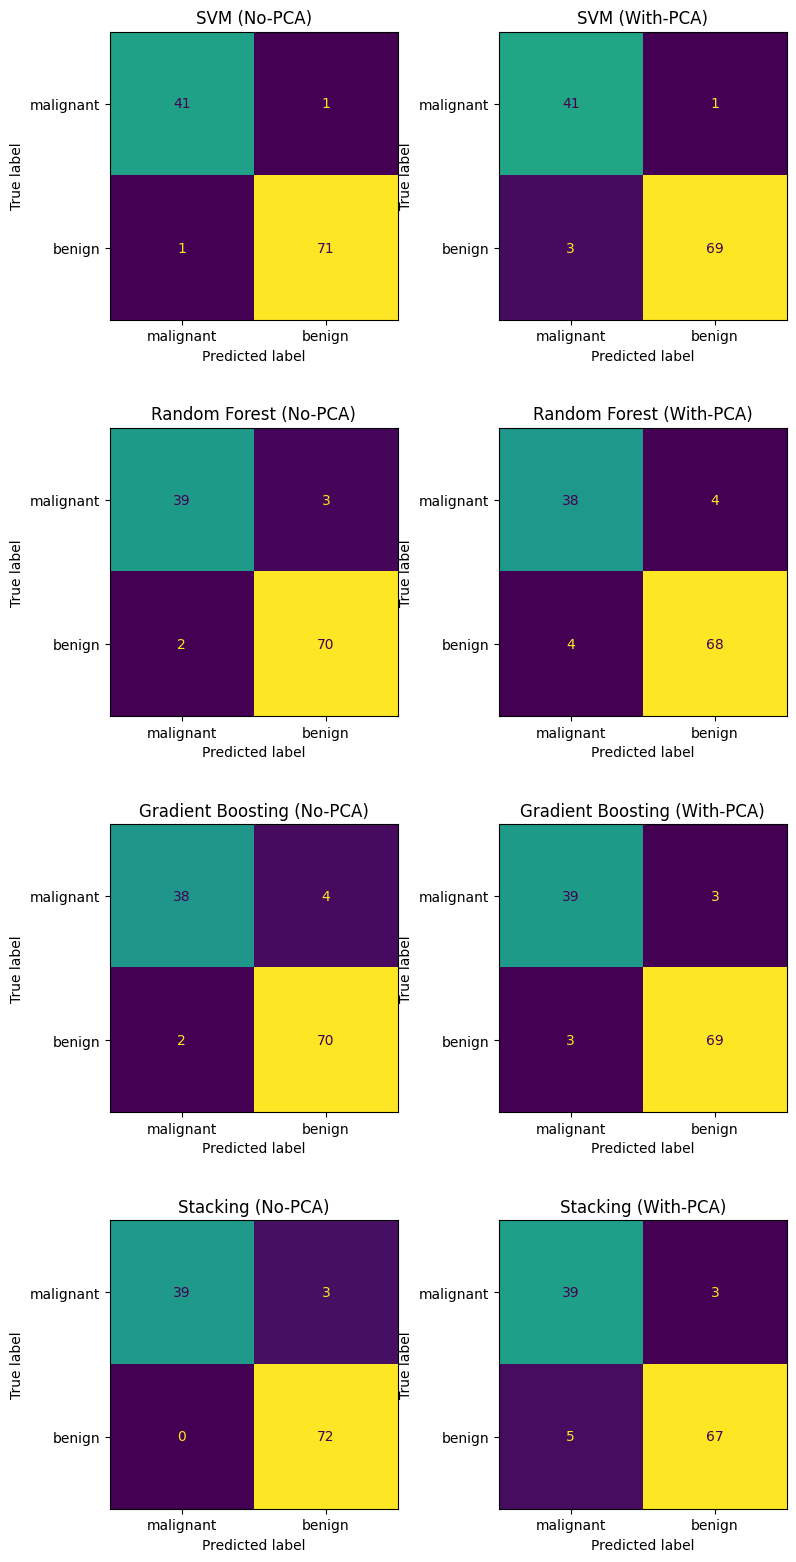

In [17]:
# Confusion matrices for selected models, No-PCA vs With-PCA
fig, axes = plt.subplots(len(selected_models), 2, figsize=(8, 4*len(selected_models)))

for i, name in enumerate(selected_models):
    for j, use_pca in enumerate([False, True]):
        res = all_results[f"{name} | {'With-PCA' if use_pca else 'No-PCA'}"]
        pipe = res['fitted_pipeline']
        pipe.fit(X_train_raw, y_train.values)
        y_pred = pipe.predict(X_test_raw)
        cm = confusion_matrix(y_test.values, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
        disp.plot(ax=axes[i,j], colorbar=False)
        axes[i,j].set_title(f"{name} ({'With-PCA' if use_pca else 'No-PCA'})")

plt.tight_layout()
plt.show()


## 11. Test Set Performance Summary (Accuracy & F1)

In [18]:
test_rows = []
for name in all_model_names:
    for use_pca in [False, True]:
        res = all_results[f"{name} | {'With-PCA' if use_pca else 'No-PCA'}"]
        pipe = res['fitted_pipeline']
        pipe.fit(X_train_raw, y_train.values)
        y_pred = pipe.predict(X_test_raw)
        acc = accuracy_score(y_test.values, y_pred)
        f1 = f1_score(y_test.values, y_pred)
        test_rows.append({
            'Model': name,
            'Setting': 'With-PCA' if use_pca else 'No-PCA',
            'Test Accuracy': round(acc, 4),
            'Test F1': round(f1, 4)
        })

test_summary = pd.DataFrame(test_rows)
test_pivot = test_summary.pivot(index='Model', columns='Setting', values=['Test Accuracy', 'Test F1'])
test_pivot


Test Accuracy          Test F1         
Setting                    No-PCA With-PCA  No-PCA With-PCA
Model                                                      
AdaBoost                   0.9561   0.9474  0.9660   0.9583
Decision Tree              0.9474   0.9298  0.9589   0.9444
Gradient Boosting          0.9474   0.9474  0.9589   0.9583
KNN                        0.9649   0.9561  0.9726   0.9655
Logistic Regression        0.9737   0.9737  0.9793   0.9790
Naive Bayes                0.9298   0.9211  0.9444   0.9379
Random Forest              0.9561   0.9298  0.9655   0.9444
SVM                        0.9825   0.9649  0.9861   0.9718
Stacking                   0.9737   0.9298  0.9796   0.9437

## 12. Observation Questions

Run the cell below to auto-generate quantitative talking points from the results above; then answer each question in a markdown cell using these numbers as evidence.


In [19]:
diffs = pd.DataFrame({
    'Model': all_model_names,
    'Avg Acc No-PCA': no_pca_scores,
    'Avg Acc With-PCA': with_pca_scores,
})
diffs['Improvement (With-PCA - No-PCA)'] = diffs['Avg Acc With-PCA'] - diffs['Avg Acc No-PCA']
diffs = diffs.sort_values('Improvement (With-PCA - No-PCA)', ascending=False)
print("Models ranked by improvement from PCA (positive = PCA helped):")
diffs


Models ranked by improvement from PCA (positive = PCA helped):


,Model,Avg Acc No-PCA,Avg Acc With-PCA,Improvement (With-PCA - No-PCA)
0,SVM,0.975824,0.980220,0.004396
4,Decision Tree,0.931868,0.936264,0.004396
8,Stacking,0.969231,0.971429,0.002198
3,Logistic Regression,0.982418,0.982418,0.000000
5,Random Forest,0.962637,0.960440,-0.002198
6,AdaBoost,0.980220,0.975824,-0.004396
2,KNN,0.971429,0.967033,-0.004396
7,Gradient Boosting,0.967033,0.962637,-0.004396
1,Naive Bayes,0.934066,0.927473,-0.006593


In [20]:
std_rows = []
for name in all_model_names:
    no_pca, with_pca = get_pair(name)
    std_rows.append({
        'Model': name,
        'Std No-PCA': no_pca['std_accuracy'],
        'Std With-PCA': with_pca['std_accuracy'],
        'Stability Change': no_pca['std_accuracy'] - with_pca['std_accuracy']  # positive = PCA more stable
    })
stability_df = pd.DataFrame(std_rows).sort_values('Stability Change', ascending=False)
print("Fold-to-fold std of accuracy (lower = more stable). 'Stability Change' > 0 means PCA reduced variance across folds.")
stability_df


Fold-to-fold std of accuracy (lower = more stable). 'Stability Change' > 0 means PCA reduced variance across folds.


,Model,Std No-PCA,Std With-PCA,Stability Change
1,Naive Bayes,0.028656,0.017855,1.080081e-02
0,SVM,0.010767,0.008223,2.543565e-03
4,Decision Tree,0.023466,0.021308,2.157623e-03
6,AdaBoost,0.018906,0.017582,1.323792e-03
3,Logistic Regression,0.005383,0.005383,-8.673617e-19
2,KNN,0.013187,0.015541,-2.353995e-03
8,Stacking,0.012815,0.016447,-3.631567e-03
5,Random Forest,0.017855,0.022628,-4.772729e-03
7,Gradient Boosting,0.015541,0.025631,-1.008975e-02


## 13. Final Conclusion

_Summarize, using the evidence generated above:_
- Which model(s) performed best overall (No-PCA vs With-PCA) on both CV and test metrics.
- General pattern: PCA tends to help models sensitive to dimensionality/multicollinearity/distance metrics (KNN, SVM, Logistic Regression) more than tree-based ensembles.
- Trade-off: PCA reduces dimensionality and training time but can discard some class-discriminative variance, occasionally lowering ensemble performance slightly.
- Recommendation: Use PCA when working with very high-dimensional, correlated features and distance-based or linear models; it is less critical (or even unhelpful) for robust tree-based ensembles like Random Forest, Gradient Boosting, and XGBoost.
